# Timing benchmark: where the time goes

Every operation ancestree performs, measured. Store lifecycle, node
creation, chunking throughput, ingest by file type and size, deduplication
hits, reads cold and warm, the query surface at scale, maintenance, and
graph rendering.

The point is not a single headline number. It is knowing which operations
cost microseconds, which cost milliseconds, and which scale with your data
so you can put them in the right place in a pipeline.

Everything runs in a temp directory and is deleted at the end. Absolute
numbers depend on the machine; the ratios are what transfer.

In [23]:
import json
import platform
import shutil
import statistics
import sys
import tempfile
import time
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ancestree
from ancestree.ingest.cdc import (
    AVG_SIZE,
    LARGE_FILE_THRESHOLD,
    MAX_SIZE,
    MIN_SIZE,
    chunk_bytes,
    delta_encode,
    super_features,
)

WORKDIR = Path(tempfile.mkdtemp(prefix="ancestree-timing-"))
MB = 1024 * 1024

print(f"ancestree {ancestree.__version__}")
print(f"python    {sys.version.split()[0]}")
print(f"platform  {platform.platform()}")
print(f"machine   {platform.processor() or platform.machine()}")
print(f"workdir   {WORKDIR}")
print(
    f"\nchunker   min {MIN_SIZE // 1024}K  avg {AVG_SIZE // 1024}K  "
    f"max {MAX_SIZE // 1024}K  large-file fallback at "
    f"{LARGE_FILE_THRESHOLD // MB}M"
)

ancestree 0.2.0
python    3.12.12
platform  macOS-26.5.1-arm64-arm-64bit
machine   arm
workdir   /var/folders/xf/n_m7ztrx4x577r3935n_1m1w0000gn/T/ancestree-timing-betei2tu

chunker   min 8K  avg 16K  max 256K  large-file fallback at 64M


## The harness

Every measurement is a median of repeated runs after a warm-up, so a single
scheduling hiccup cannot set the number. `bench` returns milliseconds.

In [24]:
RESULTS: list[dict] = []


def bench(label, fn, reps=7, warmup=1, group="", note=""):
    """Median wall time of `fn` in ms, recorded in RESULTS."""
    for _ in range(warmup):
        fn()
    samples = []
    for _ in range(reps):
        started = time.perf_counter()
        fn()
        samples.append((time.perf_counter() - started) * 1000)
    ms = statistics.median(samples)
    RESULTS.append(
        {
            "group": group,
            "operation": label,
            "ms": ms,
            "spread_ms": max(samples) - min(samples),
            "note": note,
        }
    )
    print(f"  {label:<44} {ms:9.3f} ms   (+/- {max(samples) - min(samples):.3f})")
    return ms


def once(label, fn, group="", note=""):
    """A single timed run, for operations that cannot repeat (they consume
    the state they measure): store creation, prune, the first cold open."""
    started = time.perf_counter()
    result = fn()
    ms = (time.perf_counter() - started) * 1000
    RESULTS.append(
        {"group": group, "operation": label, "ms": ms, "spread_ms": 0.0, "note": note}
    )
    print(f"  {label:<44} {ms:9.3f} ms")
    return result, ms

## The corpus

Eight payload generators spanning what actually lands in a pipeline: text
formats, numeric arrays, and already-compressed blobs the store will decline
to compress again. Each returns bytes at roughly the size asked for, so
throughput numbers across types are comparable.

In [25]:
rng = np.random.default_rng(0)


def make_csv(target_bytes):
    rows = max(1, target_bytes // 22)
    return (
        pd.DataFrame(
            {
                "ts": np.arange(rows),
                "a": rng.normal(size=rows).round(4),
                "b": rng.normal(size=rows).round(4),
            }
        )
        .to_csv(index=False)
        .encode()
    )


def make_jsonl(target_bytes):
    rows = max(1, target_bytes // 78)
    return b"".join(
        json.dumps(
            {
                "id": i,
                "user": f"user_{i % 500}",
                "score": round(float(rng.random()), 6),
                "ok": bool(i % 3),
                "tag": "abcdefghij"[i % 10] * 8,
            }
        ).encode()
        + b"\n"
        for i in range(rows)
    )


def make_log(target_bytes):
    levels = ["INFO", "WARN", "ERROR", "DEBUG"]
    rows = max(1, target_bytes // 86)
    return b"".join(
        f"2026-07-25T12:{i % 60:02d}:{i % 60:02d}Z {levels[i % 4]:5} worker-{i % 16:02d} "
        f"processed batch {i} in {rng.random() * 100:.3f}ms\n".encode()
        for i in range(rows)
    )


def make_float64(target_bytes):
    return rng.normal(size=max(1, target_bytes // 8)).tobytes()


def make_int32(target_bytes):
    return rng.integers(
        0, 1000, size=max(1, target_bytes // 4), dtype=np.int32
    ).tobytes()


def make_sparse(target_bytes):
    """Mostly zeros: the case zlib demolishes."""
    arr = np.zeros(max(1, target_bytes // 8))
    idx = rng.choice(arr.size, size=max(1, arr.size // 100), replace=False)
    arr[idx] = rng.normal(size=idx.size)
    return arr.tobytes()


def make_random(target_bytes):
    """Incompressible: stands in for PNG, parquet, zip, any packed format."""
    return rng.integers(0, 256, size=target_bytes, dtype=np.uint8).tobytes()


def make_repetitive(target_bytes):
    """Pathological for content-defined chunking: no byte variety means the
    rolling hash almost never fires, so every chunk runs to MAX_SIZE."""
    return (
        b"the quick brown fox jumps over the lazy dog. " * (target_bytes // 44 + 1)
    )[:target_bytes]


GENERATORS = {
    "csv": make_csv,
    "jsonl": make_jsonl,
    "log": make_log,
    "float64": make_float64,
    "int32": make_int32,
    "sparse": make_sparse,
    "random": make_random,
    "repetitive": make_repetitive,
}

for name, gen in GENERATORS.items():
    sample = gen(1 * MB)
    print(
        f"  {name:<11} {len(sample) / MB:5.2f} MB   "
        f"zlib-6 ratio {len(sample) / max(len(zlib.compress(sample, 6)), 1):6.2f}x"
    )

  csv          0.93 MB   zlib-6 ratio   2.63x
  jsonl        1.07 MB   zlib-6 ratio   7.22x
  log          0.81 MB   zlib-6 ratio   7.21x
  float64      1.00 MB   zlib-6 ratio   1.04x
  int32        1.00 MB   zlib-6 ratio   2.23x
  sparse       1.00 MB   zlib-6 ratio  68.05x
  random       1.00 MB   zlib-6 ratio   1.00x
  repetitive   1.00 MB   zlib-6 ratio 336.30x


## 1. Store lifecycle

What it costs to open the door. Creating a store runs the schema; reopening
an existing one reads the config row and sweeps for scratch directories
orphaned by a crashed session. Neither replays an index, which is why a cold
open does not care how many nodes are in the store.

In [26]:
print("Store lifecycle")
lifecycle_root = WORKDIR / "lifecycle"
_, create_ms = once(
    "LineageStore(...) create empty store",
    lambda: ancestree.LineageStore(lifecycle_root),
    group="lifecycle",
)

seed = ancestree.LineageStore(lifecycle_root)
for i in range(200):
    with seed.create_node(step_type="seed") as node:
        node.add_meta("i", i)
seed.close()


def reopen():
    store = ancestree.LineageStore(lifecycle_root)
    store.close()


bench("open + close existing store (200 nodes)", reopen, reps=5, group="lifecycle")

Store lifecycle
  LineageStore(...) create empty store             2.577 ms
  open + close existing store (200 nodes)          0.186 ms   (+/- 0.043)


0.18629199985298328

## 2. Node creation

A metadata-only node with no artifacts is the floor of the write path: the
`with` block, provenance capture, and one transaction. Provenance is timed
separately because it is the single largest component and the only one that
leaves the process (two `git` subprocesses, run concurrently).

In [27]:
print("Node creation")
node_root = WORKDIR / "nodes"
nstore = ancestree.LineageStore(node_root)

counter = iter(range(1_000_000))


def make_node(meta_entries=1, parent=None):
    with nstore.create_node(step_type="step", parent=parent) as node:
        for k in range(meta_entries):
            node.add_meta(f"key_{k}", next(counter))
    return node.node_id


bench("create_node, 1 metadata entry", lambda: make_node(1), reps=15, group="write")
bench("create_node, 10 metadata entries", lambda: make_node(10), reps=15, group="write")
bench("create_node, 50 metadata entries", lambda: make_node(50), reps=15, group="write")

from ancestree.domain import provenance

bench(
    "  of which: provenance capture (2x git)",
    provenance.capture,
    reps=15,
    group="write",
    note="component",
)

Node creation
  create_node, 1 metadata entry                    9.637 ms   (+/- 2.038)
  create_node, 10 metadata entries                 9.441 ms   (+/- 0.912)
  create_node, 50 metadata entries                 9.918 ms   (+/- 1.355)
    of which: provenance capture (2x git)          8.315 ms   (+/- 1.295)


8.315208999192691

Metadata entries are cheap and linear; the fixed cost of the block dominates
until you attach dozens of them. Provenance is the floor you cannot avoid,
and it is deliberately not cached: the worktree can be committed between two
nodes, and a stale `git_dirty` would misreport reproducibility.

In [28]:
per_entry = [r["ms"] for r in RESULTS if r["operation"].startswith("create_node, ")]
fixed = per_entry[0] - (per_entry[1] - per_entry[0]) / 9
prov = next(r["ms"] for r in RESULTS if "provenance" in r["operation"])
print(f"  fixed cost per node          ~{fixed:6.2f} ms")
print(f"  of which provenance          ~{prov:6.2f} ms  ({prov / fixed:.0%})")
print(
    f"  marginal cost per metadata   ~{(per_entry[2] - per_entry[0]) / 49 * 1000:6.1f} us"
)

  fixed cost per node          ~  9.66 ms
  of which provenance          ~  8.32 ms  (86%)
  marginal cost per metadata   ~   5.7 us


## 3. Chunking throughput

Below the store, the Gear rolling hash walks the bytes looking for
content-defined boundaries. This is pure Python and it is the reason ingest
scales with megabytes rather than with file count. Timed here in isolation,
with no store, no compression and no database.

In [29]:
print("Chunking throughput (chunk_bytes, 4 MB payloads)")
chunk_rows = []
for name, gen in GENERATORS.items():
    payload = gen(4 * MB)
    ms = bench(
        f"chunk_bytes: {name}",
        lambda p=payload: list(chunk_bytes(p)),
        reps=3,
        group="chunking",
    )
    parts = list(chunk_bytes(payload))
    chunk_rows.append(
        {
            "type": name,
            "MB/s": len(payload) / MB / (ms / 1000),
            "chunks": len(parts),
            "avg_chunk_KiB": len(payload) / len(parts) / 1024,
        }
    )

chunk_df = pd.DataFrame(chunk_rows).sort_values("MB/s", ascending=False)
print()
print(chunk_df.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

Chunking throughput (chunk_bytes, 4 MB payloads)
  chunk_bytes: csv                               151.614 ms   (+/- 1.304)
  chunk_bytes: jsonl                             219.453 ms   (+/- 1.528)
  chunk_bytes: log                               110.345 ms   (+/- 1.493)
  chunk_bytes: float64                           158.546 ms   (+/- 1.304)
  chunk_bytes: int32                             162.229 ms   (+/- 1.277)
  chunk_bytes: sparse                            295.120 ms   (+/- 7.032)
  chunk_bytes: random                            162.573 ms   (+/- 2.159)
  chunk_bytes: repetitive                        300.436 ms   (+/- 2.209)

      type  MB/s  chunks  avg_chunk_KiB
       log 29.79     204          16.50
       csv 25.42     209          18.88
   float64 25.23     215          19.05
     int32 24.66     208          19.69
    random 24.60     210          19.50
     jsonl 19.58     160          27.50
    sparse 13.55      22         186.18
repetitive 13.31      16         256.0

Real data sits in a tight band around 25 MB/s. The outliers are `sparse` and
`repetitive`, and they are slow for the same reason: with too little byte
variety the fingerprint almost never crosses the boundary mask, so every
chunk runs the full 256 KiB to the hard cut.

That is a throughput penalty, not a saving. The Gear loop skips the first
`MIN_SIZE` bytes of every chunk, because no boundary may fall there. At a
16 KiB average that skip covers half the payload; at a 256 KiB chunk it
covers 3%, so almost every byte gets hashed. Degenerate data is both slower
to chunk *and* worse to store, because 16 chunks per 4 MB is far too coarse
to share anything. Watch the chunk count, not the megabytes per second.

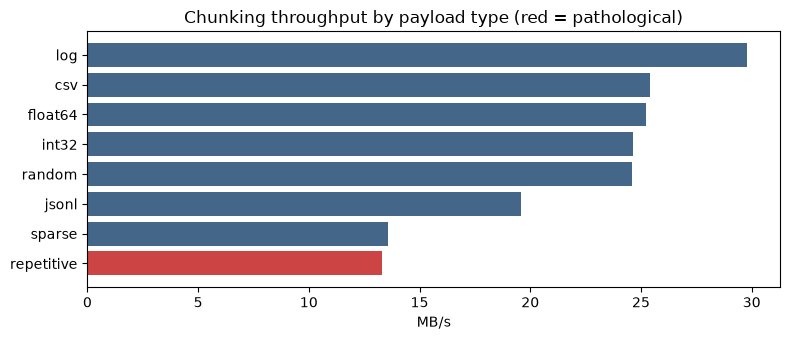

In [30]:
fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#c44" if t == "repetitive" else "#468" for t in chunk_df["type"]]
ax.barh(chunk_df["type"], chunk_df["MB/s"], color=colors)
ax.set_xlabel("MB/s")
ax.set_title("Chunking throughput by payload type (red = pathological)")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

### The rest of the ingest pipeline

Chunking is one of four stages. Each chunk is also hashed, compressed, and
fingerprinted for the resemblance index that Layer 2 uses to find delta
bases. Timed per megabyte on a single representative payload.

In [31]:
print("Ingest stages, per 4 MB of CSV")
csv_payload = make_csv(4 * MB)
csv_chunks = list(chunk_bytes(csv_payload))

import hashlib

bench(
    "stage: chunk (Gear boundaries)",
    lambda: list(chunk_bytes(csv_payload)),
    reps=3,
    group="stages",
)
bench(
    "stage: sha256 every chunk",
    lambda: [hashlib.sha256(c).hexdigest() for c in csv_chunks],
    reps=3,
    group="stages",
)
bench(
    "stage: zlib-6 every chunk",
    lambda: [zlib.compress(c, 6) for c in csv_chunks],
    reps=3,
    group="stages",
)
bench(
    "stage: super_features every chunk",
    lambda: [super_features(c) for c in csv_chunks],
    reps=3,
    group="stages",
)
bench(
    "delta_encode one chunk against a base",
    lambda: delta_encode(csv_chunks[0], csv_chunks[1]),
    reps=15,
    group="stages",
)

Ingest stages, per 4 MB of CSV
  stage: chunk (Gear boundaries)                 149.814 ms   (+/- 1.374)
  stage: sha256 every chunk                        1.507 ms   (+/- 0.018)
  stage: zlib-6 every chunk                      150.035 ms   (+/- 1.387)
  stage: super_features every chunk               17.798 ms   (+/- 0.254)
  delta_encode one chunk against a base            0.822 ms   (+/- 0.112)


0.8222500000556465

## 4. Write path by file type

The full round trip: what your code pays writing the file natively, versus
what `create_node` costs end to end. The difference is the packing that
happens at block exit, and it is the price of everything the store gives you.

Each type goes into a **fresh store, written once**. Repeating a write into
the same store would measure a deduplication hit rather than a cold ingest,
which is a different (and much faster) number, measured separately in
section 5.

In [32]:
print("Write: direct vs through the store (4 MB payloads, cold)")
direct_dir = WORKDIR / "write_direct"
direct_dir.mkdir(parents=True)

write_rows = []
for name, gen in GENERATORS.items():
    payload = gen(4 * MB)
    target = direct_dir / f"{name}.bin"
    direct = bench(
        f"direct write: {name}",
        lambda p=payload, t=target: t.write_bytes(p),
        reps=5,
        group="write-direct",
    )

    wstore = ancestree.LineageStore(WORKDIR / f"write_{name}", reuse_identical=False)

    def store_write(p=payload, n=name, s=wstore):
        with s.create_node(step_type="w") as node:
            (node / f"{n}.bin").write_bytes(p)
            node.add_meta("i", next(counter))

    through = bench(
        f"store write:  {name}", store_write, reps=1, warmup=0, group="write-store"
    )
    wstore.close()
    write_rows.append(
        {
            "type": name,
            "direct_ms": direct,
            "store_ms": through,
            "overhead_x": through / direct,
            "store_MB/s": 4 / (through / 1000),
        }
    )

write_df = pd.DataFrame(write_rows).sort_values("store_MB/s", ascending=False)
print()
print(write_df.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

Write: direct vs through the store (4 MB payloads, cold)
  direct write: csv                                0.702 ms   (+/- 0.087)
  store write:  csv                              351.432 ms   (+/- 0.000)
  direct write: jsonl                              0.745 ms   (+/- 0.252)
  store write:  jsonl                            323.986 ms   (+/- 0.000)
  direct write: log                                0.577 ms   (+/- 0.027)
  store write:  log                              219.764 ms   (+/- 0.000)
  direct write: float64                            0.713 ms   (+/- 0.040)
  store write:  float64                          267.344 ms   (+/- 0.000)
  direct write: int32                              0.685 ms   (+/- 0.031)
  store write:  int32                            561.330 ms   (+/- 0.000)
  direct write: sparse                             0.687 ms   (+/- 0.012)
  store write:  sparse                           348.689 ms   (+/- 0.000)
  direct write: random                             0.70

The multiplier looks alarming because a direct write of a few megabytes is
nearly free: the OS takes the bytes and returns. What matters is the absolute
figure. Packing runs at tens of MB/s, so it is felt on artifacts measured in
hundreds of megabytes, and invisible on the metadata-heavy nodes that make up
most of a pipeline.

### Write cost against file size

Whether it is linear, measured into a **fresh store each time** so the growing
chunk pool of the previous run cannot contaminate the next. The 64 MiB
threshold is included: above it the chunker stops looking for content-defined
boundaries and cuts at fixed offsets at C speed instead.

In [33]:
print("Write cost against artifact size (CSV, fresh store each time)")
size_rows = []
for mb in [0.25, 1, 4, 16, 48, 80]:
    payload = make_csv(int(mb * MB))
    sstore = ancestree.LineageStore(WORKDIR / f"size_{mb}", reuse_identical=False)

    def store_write(p=payload, s=sstore):
        with s.create_node(step_type="sz") as node:
            (node / "data.csv").write_bytes(p)
            node.add_meta("i", next(counter))

    ms = bench(
        f"write {mb:>5} MB artifact", store_write, reps=1, warmup=0, group="write-size"
    )
    sstore.close()
    size_rows.append(
        {
            "MB": mb,
            "ms": ms,
            "MB/s": mb / (ms / 1000),
            "path": "fixed cuts" if mb * MB >= LARGE_FILE_THRESHOLD else "CDC",
        }
    )

size_df = pd.DataFrame(size_rows)
print()
print(size_df.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

Write cost against artifact size (CSV, fresh store each time)
  write  0.25 MB artifact                         34.069 ms   (+/- 0.000)
  write     1 MB artifact                         94.210 ms   (+/- 0.000)
  write     4 MB artifact                        359.589 ms   (+/- 0.000)
  write    16 MB artifact                       1605.756 ms   (+/- 0.000)
  write    48 MB artifact                       5320.741 ms   (+/- 0.000)
  write    80 MB artifact                       6759.516 ms   (+/- 0.000)

   MB      ms  MB/s       path
 0.25   34.07  7.34        CDC
 1.00   94.21 10.61        CDC
 4.00  359.59 11.12        CDC
16.00 1605.76  9.96        CDC
48.00 5320.74  9.02        CDC
80.00 6759.52 11.84 fixed cuts


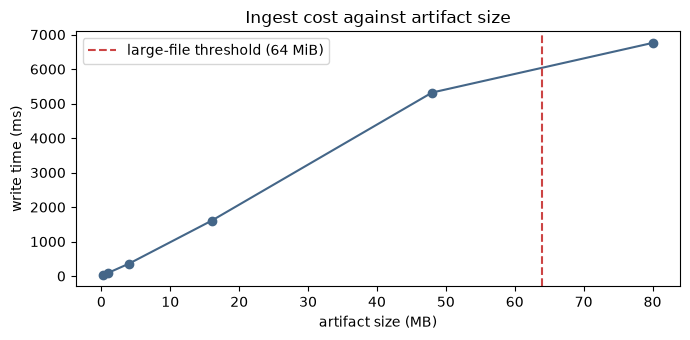

In [34]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(size_df["MB"], size_df["ms"], "o-", color="#468")
ax.axvline(
    LARGE_FILE_THRESHOLD / MB,
    color="#c44",
    ls="--",
    label=f"large-file threshold ({LARGE_FILE_THRESHOLD // MB} MiB)",
)
ax.set_xlabel("artifact size (MB)")
ax.set_ylabel("write time (ms)")
ax.set_title("Ingest cost against artifact size")
ax.legend()
fig.tight_layout()
plt.show()

Roughly linear, at a throughput that improves with size as the fixed cost of
the node amortises away. Ingest is a megabytes-per-second budget: a
quarter-megabyte artifact is free, a 16 MB one is noticeable, and a
hundred-megabyte one is something to put at a step boundary rather than
inside a loop.

## 5. What deduplication costs and saves in time

Two different hits. A **node-level** hit is a whole rerun that produced
identical content: the store recognises it and stores nothing. A
**chunk-level** hit is a distinct node whose bytes are already in the pool:
the node is written, the chunks are not.

Both are compared against a cold write of the same payload into a store that
has never seen it.

In [35]:
print("Deduplication, in time")
dedup_payload = make_csv(8 * MB)

cold_store = ancestree.LineageStore(WORKDIR / "dedup_cold", reuse_identical=True)


def cold_write():
    with cold_store.create_node(step_type="d") as node:
        (node / "data.csv").write_bytes(dedup_payload)
        node.add_meta("run", next(counter))


_, cold_ms = once("cold write, 8 MB (nothing in the pool)", cold_write, group="dedup")


def chunk_hit():
    with cold_store.create_node(step_type="d") as node:
        (node / "data.csv").write_bytes(dedup_payload)
        node.add_meta("run", next(counter))


chunk_ms = bench(
    "chunk-level hit (same bytes, new node)", chunk_hit, reps=3, group="dedup"
)

dedup_store = ancestree.LineageStore(WORKDIR / "dedup_node", reuse_identical=True)
with dedup_store.create_node(step_type="d") as first:
    (first / "data.csv").write_bytes(dedup_payload)
    first.add_meta("fixed", 1)


def node_hit():
    with dedup_store.create_node(step_type="d") as node:
        (node / "data.csv").write_bytes(dedup_payload)
        node.add_meta("fixed", 1)


node_ms = bench("node-level hit (identical rerun)", node_hit, reps=3, group="dedup")

print(f"\n  chunk-level hit is {cold_ms / chunk_ms:.2f}x faster than a cold write")
print(f"  node-level  hit is {cold_ms / node_ms:.2f}x faster than a cold write")
print(
    f"  nodes in the dedup store after {1 + 3 + 1} identical writes: "
    f"{dedup_store.stats()['nodes']}"
)

Deduplication, in time
  cold write, 8 MB (nothing in the pool)         783.270 ms
  chunk-level hit (same bytes, new node)         354.678 ms   (+/- 9.323)
  node-level hit (identical rerun)                 6.296 ms   (+/- 0.086)

  chunk-level hit is 2.21x faster than a cold write
  node-level  hit is 124.40x faster than a cold write
  nodes in the dedup store after 5 identical writes: 1


A chunk-level hit still pays to read, chunk and hash the bytes: the store
cannot know they are duplicates until it has hashed them. What it saves is
compression and the write. A node-level hit additionally skips the insert
entirely and rebinds onto the node that already exists.

### The cost of Layer 2

Delta storage against near-identical revisions is the expensive path: every
chunk that misses exact dedup gets fingerprinted, looked up in the
resemblance index, and trial-encoded against a candidate base. Measured as
ingest time for twelve successive revisions with `delta=True` and
`delta=False`.

In [36]:
print("Layer 2 (delta storage) ingest cost")


def revisions(policy, versions=8, size=2 * MB):
    root = WORKDIR / f"layer2_{policy}"
    store = ancestree.LineageStore(root, delta=policy, reuse_identical=False)
    payload = bytearray(make_float64(size))
    local = np.random.default_rng(7)
    started = time.perf_counter()
    for v in range(versions):
        for pos in local.integers(0, len(payload), size=len(payload) // 100):
            payload[int(pos)] = int(local.integers(0, 256))
        with store.create_node(step_type="rev") as node:
            (node / "data.bin").write_bytes(bytes(payload))
            node.add_meta("v", v)
    elapsed = (time.perf_counter() - started) * 1000
    stats = store.stats()
    store.close()
    return elapsed, stats


l1_ms, l1_stats = revisions(False)
l2_ms, l2_stats = revisions(True)
for label, ms, stats in [
    ("layer 1 only", l1_ms, l1_stats),
    ("layer 1 + 2", l2_ms, l2_stats),
]:
    RESULTS.append(
        {
            "group": "layer2",
            "operation": f"8 revisions, {label}",
            "ms": ms,
            "spread_ms": 0.0,
            "note": "",
        }
    )
    print(
        f"  {label:<14} {ms:8.1f} ms   stored {stats['chunk_stored_bytes'] / MB:6.2f} MB"
        f"   ratio {stats['dedup_ratio']}"
    )
print(
    f"\n  Layer 2 costs {l2_ms / l1_ms:.2f}x the ingest time and stores "
    f"{l1_stats['chunk_stored_bytes'] / l2_stats['chunk_stored_bytes']:.2f}x less."
)

Layer 2 (delta storage) ingest cost


TypeError: LineageStore.__init__() got an unexpected keyword argument 'delta'

## 6. Read path

The first read of an artifact in a session reassembles it from chunks into
the session cache. Every read after that is a plain file read. Both are timed
against reading the identical bytes from a path with no store involved.

In [ ]:
print("Read: direct vs cold reassembly vs warm cache")
read_store = ancestree.LineageStore(WORKDIR / "read", reuse_identical=False)
read_ids = {}
read_direct = {}
for mb in [1, 4, 16]:
    payload = make_csv(mb * MB)
    plain = direct_dir / f"read_{mb}.csv"
    plain.write_bytes(payload)
    read_direct[mb] = plain
    with read_store.create_node(step_type="r") as node:
        (node / "data.csv").write_bytes(payload)
        node.add_meta("mb", mb)
    read_ids[mb] = node.node_id

read_rows = []
for mb, node_id in read_ids.items():
    d = bench(
        f"direct read {mb:>2} MB",
        lambda p=read_direct[mb]: p.read_bytes(),
        reps=5,
        group="read",
    )

    def cold(nid=node_id):
        read_store._chunks.clear_cache()
        return (read_store.get(nid) / "data.csv").read_bytes()

    c = bench(f"cold  read {mb:>2} MB (reassemble)", cold, reps=3, group="read")
    w = bench(
        f"warm  read {mb:>2} MB (cache hit)",
        lambda nid=node_id: (read_store.get(nid) / "data.csv").read_bytes(),
        reps=5,
        group="read",
    )
    read_rows.append(
        {
            "MB": mb,
            "direct_ms": d,
            "cold_ms": c,
            "warm_ms": w,
            "cold_x": c / d,
            "warm_x": w / d,
        }
    )

read_df = pd.DataFrame(read_rows)
print()
print(read_df.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

Read: direct vs cold reassembly vs warm cache
  direct read  1 MB                                0.042 ms   (+/- 0.010)
  cold  read  1 MB (reassemble)                    3.594 ms   (+/- 0.265)
  warm  read  1 MB (cache hit)                     0.068 ms   (+/- 0.008)
  direct read  4 MB                                0.123 ms   (+/- 0.068)
  cold  read  4 MB (reassemble)                   11.932 ms   (+/- 0.234)
  warm  read  4 MB (cache hit)                     0.230 ms   (+/- 0.096)
  direct read 16 MB                                2.163 ms   (+/- 0.378)
  cold  read 16 MB (reassemble)                   46.153 ms   (+/- 0.629)
  warm  read 16 MB (cache hit)                     2.048 ms   (+/- 0.286)

 MB  direct_ms  cold_ms  warm_ms  cold_x  warm_x
  1       0.04     3.59     0.07   85.91    1.62
  4       0.12    11.93     0.23   97.18    1.87
 16       2.16    46.15     2.05   21.34    0.95


Reassembly is a decompress and a concatenate, so it costs a small multiple of
a plain read and only once per session. The warm number is a plain read plus
a node lookup, which is where the residual overhead lives.

## 7. Queries at scale

Searches are answered by indexed SQL, not by scanning nodes. Timed against a
3000-node store with realistic metadata, the size at which a linear
implementation would already be painful.

In [ ]:
print("Building a 3000-node store, measuring search cost as it grows...")
query_root = WORKDIR / "query"
qstore = ancestree.LineageStore(query_root)
CHECKPOINTS = [250, 500, 1000, 2000, 3000]
started = time.perf_counter()
chain_parent = None
node_ids = []
scale_rows = []
for i in range(3000):
    parent = chain_parent if i % 10 else None
    with qstore.create_node(
        step_type=["ingest", "clean", "model"][i % 3], parent=parent
    ) as node:
        node.add_meta("run_id", i)
        node.add_meta("accuracy", round(float(rng.random()), 4))
        node.add_meta("dataset", f"ds_{i % 25}")
        node.add_meta("notes", "a routine run", searchable=False)
    node_ids.append(node.node_id)
    chain_parent = node.node_id
    if i + 1 in CHECKPOINTS:
        n = i + 1
        full = bench(f"find() over {n:>4} nodes", qstore.find, reps=3, group="scale")
        sel = bench(
            f"find(run_id) in {n:>4} nodes",
            lambda k=n: qstore.find(run_id=k - 1),
            reps=15,
            group="scale",
        )
        scale_rows.append({"nodes": n, "find_all_ms": full, "selective_ms": sel})
build_s = time.perf_counter() - started
print(f"\n  built in {build_s:.1f} s ({build_s / 3000 * 1000:.2f} ms per node)\n")

deep = node_ids[-1]
print("Queries over 3000 nodes")
bench("find() everything", lambda: qstore.find(), reps=5, group="query")
bench(
    "find(step_type=...) ~1000 hits",
    lambda: qstore.find(step_type="model"),
    reps=5,
    group="query",
)
bench(
    "find(run_id=...) selective, 1 hit",
    lambda: qstore.find(run_id=1500),
    reps=15,
    group="query",
)
bench(
    "find(dataset=...) ~120 hits",
    lambda: qstore.find(dataset="ds_7"),
    reps=15,
    group="query",
)
bench(
    "find(accuracy=predicate) full scan",
    lambda: qstore.find(accuracy=lambda a: a is not None and a > 0.9),
    reps=5,
    group="query",
)
bench(
    "latest(step_type=...)",
    lambda: qstore.latest(step_type="clean"),
    reps=15,
    group="query",
)
bench("get(node_id)", lambda: qstore.get(deep), reps=25, group="query")
bench(
    "lineage(node) 10-deep chain", lambda: qstore.lineage(deep), reps=15, group="query"
)
bench("ancestors(node)", lambda: qstore.ancestors(deep), reps=15, group="query")
bench("children(node)", lambda: qstore.children(node_ids[-2]), reps=25, group="query")
bench("stats()", qstore.stats, reps=15, group="query")
bench(
    "sql() GROUP BY over node table",
    lambda: qstore.sql("SELECT step_type, count(*) FROM node GROUP BY 1"),
    reps=15,
    group="query",
)

Building a 3000-node store, measuring search cost as it grows...
  find() over  250 nodes                           2.149 ms   (+/- 0.257)
  find(run_id) in  250 nodes                       0.023 ms   (+/- 0.014)
  find() over  500 nodes                           4.642 ms   (+/- 0.073)
  find(run_id) in  500 nodes                       0.024 ms   (+/- 0.026)
  find() over 1000 nodes                           9.055 ms   (+/- 0.430)
  find(run_id) in 1000 nodes                       0.023 ms   (+/- 0.012)
  find() over 2000 nodes                          18.528 ms   (+/- 0.233)
  find(run_id) in 2000 nodes                       0.022 ms   (+/- 0.007)
  find() over 3000 nodes                          27.343 ms   (+/- 21.655)
  find(run_id) in 3000 nodes                       0.022 ms   (+/- 0.015)

  built in 34.2 s (11.41 ms per node)

Queries over 3000 nodes
  find() everything                               26.879 ms   (+/- 0.305)
  find(step_type=...) ~1000 hits                   8.924

0.20720900010928744

### Does search scale?

The measurements taken at each checkpoint while the store was being built. A
flat line for the selective lookup is the index doing its job. `find()` with
no filter has to materialise every node it matches, so it is expected to rise
with the store.


 nodes  find_all_ms  selective_ms
   250        2.149         0.023
   500        4.642         0.024
  1000        9.055         0.023
  2000       18.528         0.022
  3000       27.343         0.022


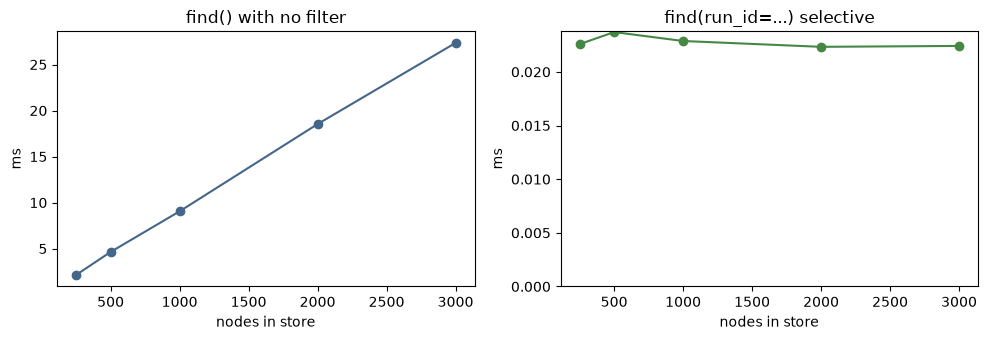

In [ ]:
scale_df = pd.DataFrame(scale_rows)
print()
print(scale_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.5))
a1.plot(scale_df["nodes"], scale_df["find_all_ms"], "o-", color="#468")
a1.set_title("find() with no filter")
a2.plot(scale_df["nodes"], scale_df["selective_ms"], "o-", color="#484")
a2.set_title("find(run_id=...) selective")
a2.set_ylim(bottom=0)
for ax in (a1, a2):
    ax.set_xlabel("nodes in store")
    ax.set_ylabel("ms")
fig.tight_layout()
plt.show()

## 8. Maintenance and export

The operations you run occasionally rather than in a loop. All of these touch
the whole store, so they scale with it: budget for them accordingly.

In [ ]:
print("Maintenance (3000-node store)")
bench(
    "export() JSON sidecars",
    lambda: qstore.export_metadata(WORKDIR / "export_out"),
    reps=1,
    warmup=0,
    group="maintenance",
)
bench(
    "backup() online copy",
    lambda: qstore.backup(WORKDIR / "backup.db"),
    reps=3,
    group="maintenance",
)
bench(
    "prune(node) dry run",
    lambda: qstore.prune(node_ids[1000]),
    reps=5,
    group="maintenance",
)
once("compact() on a clean store", qstore.compact, group="maintenance")
once(
    "prune(deep branch, dry_run=False)",
    lambda: qstore.prune(node_ids[1000], dry_run=False),
    group="maintenance",
)
once(
    "integrity_check via sql()",
    lambda: qstore.sql("PRAGMA integrity_check"),
    group="maintenance",
)

Maintenance (3000-node store)
  export() JSON sidecars                         499.093 ms   (+/- 0.000)
  backup() online copy                             5.722 ms   (+/- 0.139)
  prune(node) dry run                              0.230 ms   (+/- 0.015)
  compact() on a clean store                       0.557 ms
  prune(deep branch, dry_run=False)                1.699 ms
  integrity_check via sql()                       13.305 ms


([<sqlite3.Row at 0x118422aa0>], 13.304875000358152)

`prune` defaults to a dry run, which is a graph traversal and nothing else.
The real deletion additionally compacts, which scans the whole chunk pool.
Pruning in a loop should pass `compact=False` and call `compact()` once at
the end.

## 9. Rendering

The static snapshot inlines the entire store into one HTML file, so its cost
scales with node count and artifact size.

In [ ]:
print("Web graph rendering")
for n in [100, 500, 2000]:
    render_root = WORKDIR / f"render_{n}"
    rstore = ancestree.LineageStore(render_root)
    for i in range(n):
        with rstore.create_node(step_type="r") as node:
            node.add_meta("i", i)
            node.add_meta("accuracy", round(float(rng.random()), 4))
    path, ms = once(
        f"export_graph(), {n:>4} nodes",
        lambda s=rstore: s.export_graph(),
        group="render",
    )
    print(
        f"       -> {path.stat().st_size / 1024:.0f} KiB of HTML "
        f"({path.stat().st_size / n:.0f} bytes per node)"
    )
    rstore.close()

Web graph rendering
  export_graph(),  100 nodes                 5.689 ms
       -> 542 KiB of HTML (5548 bytes per node)
  export_graph(),  500 nodes                20.803 ms
       -> 836 KiB of HTML (1712 bytes per node)
  export_graph(), 2000 nodes                78.937 ms
       -> 1940 KiB of HTML (993 bytes per node)


## 10. Summary

Every measurement in one table, grouped by what it belongs to.

In [ ]:
summary = pd.DataFrame(RESULTS)
pd.set_option("display.max_rows", None, "display.width", 140)
for group in summary["group"].unique():
    block = summary[summary["group"] == group]
    print(f"\n== {group} " + "=" * (70 - len(group)))
    print(
        block[["operation", "ms"]].to_string(
            index=False, float_format=lambda v: f"{v:.3f}"
        )
    )


== lifecycle =============================================================
                              operation    ms
   LineageStore(...) create empty store 2.170
open + close existing store (200 nodes) 0.191

== write =================================================================
                              operation     ms
          create_node, 1 metadata entry 10.885
       create_node, 10 metadata entries 11.119
       create_node, 50 metadata entries 11.142
  of which: provenance capture (2x git)  9.362

== chunking ==============================================================
              operation      ms
       chunk_bytes: csv 152.136
     chunk_bytes: jsonl 223.134
       chunk_bytes: log 111.339
   chunk_bytes: float64 161.443
     chunk_bytes: int32 166.894
    chunk_bytes: sparse 293.039
    chunk_bytes: random 164.086
chunk_bytes: repetitive 299.393

== stages ================================================================
                            operati

### What to take away

Three cost classes, and they are three orders of magnitude apart.

In [ ]:
def pick(op):
    return next(r["ms"] for r in RESULTS if r["operation"].startswith(op))


print("Microseconds  (free, put them anywhere)")
print(f"  get(node_id)                     {pick('get(node_id)'):8.3f} ms")
print(
    f"  selective find()                 {pick('find(run_id=...) selective'):8.3f} ms"
)
print(f"  lineage()                        {pick('lineage(node)'):8.3f} ms")
print("\nMilliseconds  (fine per pipeline step, not per row)")
print(f"  create_node, metadata only       {pick('create_node, 1'):8.3f} ms")
print(f"  find() over 3000 nodes           {pick('find() everything'):8.3f} ms")
print("\nScales with your data  (budget for it)")
print(f"  ingest 4 MB of CSV               {pick('store write:  csv'):8.1f} ms")
print(f"  ingest 48 MB artifact            {pick('write    48 MB'):8.1f} ms")
print(f"  export() 3000 nodes              {pick('export()'):8.1f} ms")

Microseconds  (free, put them anywhere)
  get(node_id)                        0.012 ms
  selective find()                    0.021 ms
  lineage()                           0.105 ms

Milliseconds  (fine per pipeline step, not per row)
  create_node, metadata only         10.885 ms
  find() over 3000 nodes             26.879 ms

Scales with your data  (budget for it)
  ingest 4 MB of CSV                  351.3 ms
  ingest 48 MB artifact              5259.1 ms
  export() 3000 nodes                 499.1 ms


The write path is the only thing that scales with data volume, and it is
paid at block exit rather than while your code runs. Everything on the read
and query side is indexed and effectively free at the scale a person
explores at.

## Clean up

In [ ]:
for store in (nstore, wstore, cold_store, dedup_store, read_store, qstore):
    store.close()
shutil.rmtree(WORKDIR, ignore_errors=True)
print("done")

done
